In [123]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta, binom, betabinom, norm,multivariate_normal
from scipy.special import expit

In [124]:
mean_1 = np.array([1, 1])
mean_2 = np.array([-1, -1])
sigma = np.eye(2)
N = 200
c1_n = 100
c1_p = c1_n / N
class1 = multivariate_normal(mean_1, sigma)
class1_samples  = class1.rvs(c1_n)
class1_test = class1.rvs(c1_n)
class1_mu = np.mean(class1_samples, axis=0)
class2 = multivariate_normal(mean_2, sigma)
class2_samples  = class2.rvs(N-c1_n)
class2_test = class2.rvs(N-c1_n)
class2_mu = np.mean(class2_samples, axis=0)
c2_p = 1 - c1_p
all_test = np.vstack((class1_test,class2_test))

In [125]:

s_1 = np.cov(class1_samples, rowvar=False)
s_1 =  s_1 / c1_n
s_2 = np.cov(class2_samples, rowvar=False)
s_2 = s_2 / (N - c1_n)
s = s_1 * (c1_n/N) + s_2 * ((N - c1_n)/N)

In [126]:
w = np.linalg.inv(s) @ (class1_mu - class2_mu)
w_0 = -0.5 * class1_mu.T @ np.linalg.inv(s) @ class1_mu + 0.5 * class2_mu.T @ np.linalg.inv(s) @ class2_mu + np.log(c1_p/c2_p)

In [127]:
total_correct = 0
total_seen = 0
for sample in class1_test:
    val = w.T @ sample + w_0
    predicted = expit(val)
    if predicted >= 0.5:
        total_correct += 1
    total_seen += 1
for sample in class2_test:
    val = w.T @ sample + w_0
    predicted = 1-expit(val)
    if predicted > 0.5:
        total_correct += 1
    total_seen += 1
print(f"Percent classification is {100*total_correct/total_seen} % ")

Percent classification is 92.0 % 


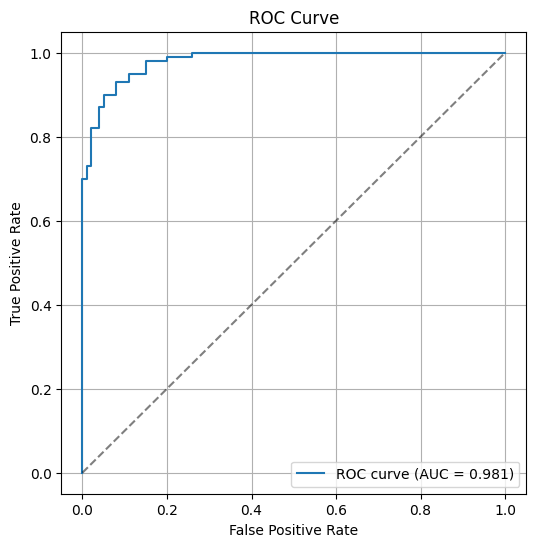

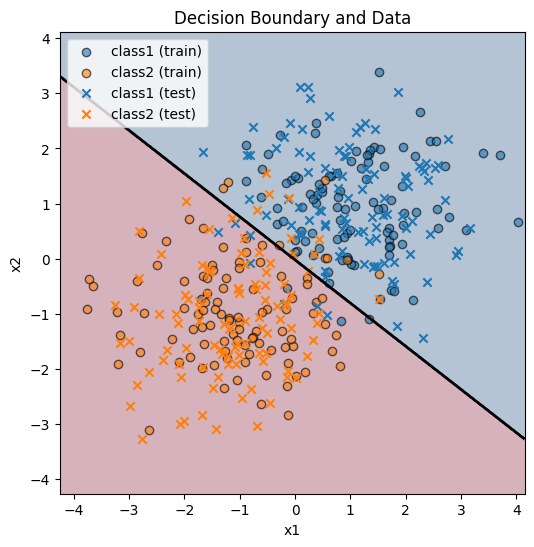

In [128]:
# Prepare test set and scores
import numpy as np
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# X_test: N x 2, y_test: N (1 for class1, 0 for class2)
X_test = np.vstack((class1_test, class2_test))
y_test = np.hstack((np.ones(len(class1_test)), np.zeros(len(class2_test))))

# raw scores (decision function) and probabilities
scores = X_test @ w + w_0            # shape (N,)
probs = expit(scores)                # probabilities in (0,1)

# Compute ROC
fpr, tpr, thresholds = roc_curve(y_test, scores)  # use scores or probs
roc_auc = auc(fpr, tpr)

# Plot ROC
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0,1], [0,1], 'k--', alpha=0.5)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# Plot decision boundary over feature space
h = 0.02  # mesh step size
x_min, x_max = X_test[:,0].min() - 1, X_test[:,0].max() + 1
y_min, y_max = X_test[:,1].min() - 1, X_test[:,1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
grid = np.c_[xx.ravel(), yy.ravel()]
Z_scores = grid @ w + w_0
Z = expit(Z_scores).reshape(xx.shape)

plt.figure(figsize=(6,6))
# contour at probability 0.5 -> decision boundary
cs = plt.contour(xx, yy, Z, levels=[0.5], colors='k', linewidths=2)
plt.contourf(xx, yy, Z, levels=20, cmap='RdBu', alpha=0.3)

# scatter points
plt.scatter(class1_samples[:,0], class1_samples[:,1], c='tab:blue', edgecolor='k', label='class1 (train)', alpha=0.6)
plt.scatter(class2_samples[:,0], class2_samples[:,1], c='tab:orange', edgecolor='k', label='class2 (train)', alpha=0.6)
plt.scatter(class1_test[:,0], class1_test[:,1], c='tab:blue', marker='x', label='class1 (test)')
plt.scatter(class2_test[:,0], class2_test[:,1], c='tab:orange', marker='x', label='class2 (test)')

plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Decision Boundary and Data')
plt.legend()
plt.show()

This is the logistic regression classifier

In [129]:
w_logit = np.array([0, 0])
design_matrix =  np.vstack((class1_samples, class2_samples))
labels = np.hstack((np.ones(c1_n), np.zeros(N - c1_n)))
num_epochs = 20
for epoch in range(num_epochs):
    r_vector = np.array([])
    predicted_vector = np.array([])
    for i in range(N):
        xi = design_matrix[i]
        yi = labels[i]
        val = w_logit.T @ xi
        predicted = expit(val)
        predicted_vector = np.append(predicted_vector, predicted)
        r_vector  = np.append(r_vector, predicted*(1 - predicted))
    epsilon = 1e-8  # small value to regularize the diagonal
    R = np.diag(r_vector) + np.eye(N) * epsilon
    z = design_matrix @ w_logit - np.linalg.inv(R) @ (np.array(predicted_vector) - labels)
    w_logit = np.linalg.inv(design_matrix.T @ R @ design_matrix) @ (design_matrix.T @ R @ z)

In [130]:
total_correct = 0
total_seen = 0
for sample in class1_test:
    val = w_logit.T @ sample
    predicted = expit(val)
    if predicted >= 0.5:
        total_correct += 1
    total_seen += 1
for sample in class2_test:
    val = w_logit.T @ sample
    predicted = 1-expit(val)
    if predicted > 0.5:
        total_correct += 1
    total_seen += 1
print(f"Percent classification is {100*total_correct/total_seen} % ")

Percent classification is 91.5 % 
